In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_validate,StratifiedKFold,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE,ADASYN
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,make_scorer,cohen_kappa_score,matthews_corrcoef,confusion_matrix,classification_report


In [2]:
#Read CSV file
data=pd.read_csv("bank-additional-full.csv",sep=";")

In [3]:
#Drop Leakage feature
data=data.drop('duration',axis=1)

In [4]:
#Handling "Unknown" values
AllColumns=data.select_dtypes(include='object').columns
for col in AllColumns:
  data[col]=data[col].replace('unknown',data[col].mode()[0])

In [5]:
#Label Encoding
data['y']=data['y'].map({'yes':1,'no':0})

In [6]:
# One Hot Encoding
data=pd.get_dummies(data,drop_first=True)

In [7]:
#Feature and Target Spliting
X=data.drop('y',axis=1)
y=data['y']

In [8]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
#Scaling
scaler=StandardScaler()
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[-0.77033007,  0.88631588,  0.19658384, ..., -0.4964409 ,
         0.39944711, -0.18627755],
       [-0.28972159, -0.56702251,  0.19658384, ..., -0.4964409 ,
         0.39944711, -0.18627755],
       [ 3.17065947, -0.20368791,  0.19658384, ..., -0.4964409 ,
         0.39944711, -0.18627755],
       ...,
       [-0.67420837, -0.56702251,  0.19658384, ..., -0.4964409 ,
        -2.50346033, -0.18627755],
       [ 0.38313029,  1.61298507,  0.19658384, ..., -0.4964409 ,
         0.39944711, -0.18627755],
       [ 0.19088689,  0.88631588,  0.19658384, ..., -0.4964409 ,
         0.39944711, -0.18627755]])

In [10]:
#sampling techniques
smote=SMOTE(random_state=42)
adasyn=ADASYN(random_state=42)

In [11]:
#Evaluation Matrices
kappa=make_scorer(cohen_kappa_score)
mcc= make_scorer(matthews_corrcoef)
Scoring={
    'accuracy':'accuracy',
    'precision':'precision',
    'recall':'recall',
    'f1':'f1',
    'roc_auc':'roc_auc',
    'kappa':kappa,
    'mcc':mcc
}

In [12]:
#models
models={
    "Decision_Tree":DecisionTreeClassifier(random_state=42),
    "Random_Forest":RandomForestClassifier(random_state=42),
    "Logistic_Regression":LogisticRegression(random_state=42),
    "KNN":KNeighborsClassifier(),
    "MLP":MLPClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42)
}

In [13]:
# Hyperparameter Dictionary

random_params = {
    "Decision_Tree": {'model__max_depth': [5, 10],'model__min_samples_split': [2, 5] },
    "Random_Forest": {'model__n_estimators': [50, 100],'model__max_depth': [5, 10]},
    "Logistic_Regression": {'model__C': [0.1, 1]},
    "KNN": {'model__n_neighbors': [3, 5]},
    "MLP": {'model__hidden_layer_sizes': [(50,)],'model__activation': ['relu']},
    "XGBoost": {'model__n_estimators': [50, 100],'model__max_depth': [3, 5]}
}

In [14]:
#Cross validation setup
skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
def Hyperparameter_Tuning(X, y, Sampler, label):

    best_models={}
    all_results=[]
    top_2_models = {}
    print(f"\n======== {label} ========")
    for name, model in models.items():
        # Pipeline
        pipeline = Pipeline([
            ('sampler', Sampler),
            ('model', model)
        ])
        # Random Search
        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=random_params[name],
            n_iter=10,
            cv=skf,
            scoring=Scoring,
            refit='f1',
            n_jobs=-1,
            random_state=42
        )
        # Cross validation  + Tuning
        random_search.fit(X, y)

        # Store best trained model
        best_models[name] = random_search.best_estimator_

        # Mean CV Scores
        accuracy = np.max(random_search.cv_results_['mean_test_accuracy'])
        precision = np.max(random_search.cv_results_['mean_test_precision'])
        recall = np.max(random_search.cv_results_['mean_test_recall'])
        f1 = np.max(random_search.cv_results_['mean_test_f1'])
        roc_auc = np.max(random_search.cv_results_['mean_test_roc_auc'])
        kappa = np.max(random_search.cv_results_['mean_test_kappa'])
        mcc = np.max(random_search.cv_results_['mean_test_mcc'])

        # Store results
        all_results.append({
            'Model': name,
            'Best_Params': random_search.best_params_,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'ROC_AUC': roc_auc,
            'Kappa': kappa,
            'MCC': mcc
        })

    #sorting the reslut to get best 2 models
    sorted_results = sorted(
    all_results,
    key=lambda x: x['Recall'],
    reverse=True
    )
    #print all results
    for result in sorted_results:

        print(f"\nModel: {result['Model']}")

        print("Best Hyperparameters:")
        print(result['Best_Params'])

        print(f"Accuracy : {result['Accuracy']:.4f}")
        print(f"Precision: {result['Precision']:.4f}")
        print(f"Recall   : {result['Recall']:.4f}")
        print(f"F1 Score : {result['F1']:.4f}")
        print(f"ROC AUC  : {result['ROC_AUC']:.4f}")
        print(f"Kappa    : {result['Kappa']:.4f}")
        print(f"MCC      : {result['MCC']:.4f}")
    print("\n===== TOP 2 MODELS =====")
    for result in sorted_results[:2]:
      print(f"\nModel: {result['Model']}")
      print(f"recall : {result['Recall']:.4f}")
      print("Best Parameters:")
      print(result['Best_Params'])
      Model_Name=result["Model"]
      top_2_models[Model_Name]=best_models[Model_Name]
    return top_2_models

In [16]:
best_Models_Baseline=Hyperparameter_Tuning(X_train,y_train,'passthrough',"Baseline(No sampling)")

best_Models_smote=Hyperparameter_Tuning(X_train,y_train,smote,"SMOTE")

best_Models_adasyn=Hyperparameter_Tuning(X_train,y_train,adasyn,"ADASYN")


======== Baseline(No sampling) ========


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modu


Model: KNN
Best Hyperparameters:
{'model__n_neighbors': 5}
Accuracy : 0.8884
Precision: 0.5089
Recall   : 0.2877
F1 Score : 0.3574
ROC AUC  : 0.7230
Kappa    : 0.3022
MCC      : 0.3194

Model: Decision_Tree
Best Hyperparameters:
{'model__min_samples_split': 2, 'model__max_depth': 5}
Accuracy : 0.9002
Precision: 0.6406
Recall   : 0.2732
F1 Score : 0.3712
ROC AUC  : 0.7788
Kappa    : 0.3272
MCC      : 0.3665

Model: XGBoost
Best Hyperparameters:
{'model__n_estimators': 100, 'model__max_depth': 5}
Accuracy : 0.9005
Precision: 0.6599
Recall   : 0.2672
F1 Score : 0.3718
ROC AUC  : 0.7964
Kappa    : 0.3257
MCC      : 0.3616

Model: Random_Forest
Best Hyperparameters:
{'model__n_estimators': 50, 'model__max_depth': 10}
Accuracy : 0.8995
Precision: 0.7047
Recall   : 0.2174
F1 Score : 0.3273
ROC AUC  : 0.7949
Kappa    : 0.2879
MCC      : 0.3420

Model: Logistic_Regression
Best Hyperparameters:
{'model__C': 0.1}
Accuracy : 0.8992
Precision: 0.6909
Recall   : 0.1996
F1 Score : 0.3073
ROC AUC  : 

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modu


Model: Random_Forest
Best Hyperparameters:
{'model__n_estimators': 50, 'model__max_depth': 10}
Accuracy : 0.8629
Precision: 0.4197
Recall   : 0.6094
F1 Score : 0.4828
ROC AUC  : 0.7829
Kappa    : 0.4058
MCC      : 0.4120

Model: Logistic_Regression
Best Hyperparameters:
{'model__C': 1}
Accuracy : 0.8031
Precision: 0.3033
Recall   : 0.5660
F1 Score : 0.3936
ROC AUC  : 0.7492
Kappa    : 0.2894
MCC      : 0.3101

Model: Decision_Tree
Best Hyperparameters:
{'model__min_samples_split': 2, 'model__max_depth': 5}
Accuracy : 0.8668
Precision: 0.4236
Recall   : 0.5318
F1 Score : 0.4715
ROC AUC  : 0.7416
Kappa    : 0.3957
MCC      : 0.3991

Model: KNN
Best Hyperparameters:
{'model__n_neighbors': 5}
Accuracy : 0.8371
Precision: 0.3312
Recall   : 0.4933
F1 Score : 0.3902
ROC AUC  : 0.7249
Kappa    : 0.2940
MCC      : 0.3030

Model: XGBoost
Best Hyperparameters:
{'model__n_estimators': 50, 'model__max_depth': 3}
Accuracy : 0.8846
Precision: 0.4858
Recall   : 0.4661
F1 Score : 0.4555
ROC AUC  : 0.7

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modu


Model: Random_Forest
Best Hyperparameters:
{'model__n_estimators': 100, 'model__max_depth': 10}
Accuracy : 0.8565
Precision: 0.4034
Recall   : 0.6336
F1 Score : 0.4732
ROC AUC  : 0.7795
Kappa    : 0.3930
MCC      : 0.4011

Model: Decision_Tree
Best Hyperparameters:
{'model__min_samples_split': 2, 'model__max_depth': 5}
Accuracy : 0.8477
Precision: 0.3666
Recall   : 0.5919
F1 Score : 0.4237
ROC AUC  : 0.7415
Kappa    : 0.3261
MCC      : 0.3470

Model: MLP
Best Hyperparameters:
{'model__hidden_layer_sizes': (50,), 'model__activation': 'relu'}
Accuracy : 0.6574
Precision: 0.2429
Recall   : 0.5568
F1 Score : 0.3031
ROC AUC  : 0.6983
Kappa    : 0.1760
MCC      : 0.1945

Model: Logistic_Regression
Best Hyperparameters:
{'model__C': 0.1}
Accuracy : 0.7565
Precision: 0.2422
Recall   : 0.5442
F1 Score : 0.3348
ROC AUC  : 0.7176
Kappa    : 0.2120
MCC      : 0.2381

Model: KNN
Best Hyperparameters:
{'model__n_neighbors': 5}
Accuracy : 0.8306
Precision: 0.3188
Recall   : 0.4997
F1 Score : 0.3785


In [17]:
final_results=[]
def Final_Model_Evaluation_Test_data(best_models, X_test, y_test, label):

    print(f"\n========== FINAL TEST RESULTS : {label} ==========")
    for name, model in best_models.items():
        print(f"\n===== {name} =====")
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

        #Calculate scores
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        kappa = cohen_kappa_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)

        final_results.append({
            'Sampling': label,
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'Kappa': kappa,
            'MCC': mcc
        })

        # Print Scores
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(f"ROC AUC  : {roc_auc:.4f}")
        print(f"Kappa    : {kappa:.4f}")
        print(f"MCC      : {mcc:.4f}")

        # Confusion Matrix
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

In [18]:
Final_Model_Evaluation_Test_data(best_Models_Baseline,X_test,y_test,"Baseline")

Final_Model_Evaluation_Test_data(best_Models_smote,X_test,y_test,"SMOTE")

Final_Model_Evaluation_Test_data(best_Models_adasyn, X_test,y_test, "ADASYN")


========== FINAL TEST RESULTS : Baseline ==========

===== KNN =====
Accuracy : 0.8937
Precision: 0.5524
Recall   : 0.2953
F1 Score : 0.3848
ROC AUC  : 0.7399
Kappa    : 0.3324
MCC      : 0.3521

Confusion Matrix:
[[7088  222]
 [ 654  274]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.55      0.30      0.38       928

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238


===== Decision_Tree =====
Accuracy : 0.9022
Precision: 0.6805
Recall   : 0.2478
F1 Score : 0.3633
ROC AUC  : 0.7908
Kappa    : 0.3226
MCC      : 0.3715

Confusion Matrix:
[[7202  108]
 [ 698  230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.68      0.25      0.36       928

    accuracy        

In [19]:
results_df = pd.DataFrame(final_results)
results_df.to_csv(
    "Final_Model_Results.csv",
    index=False
)

In [20]:
!pip install shap lime -q
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [21]:
# Main Model
rf_pipeline = best_Models_smote["Random_Forest"]
# Comparison Model
dt_pipeline = best_Models_adasyn["Decision_Tree"]

#Extraact actual model from pipeline
rf_model = rf_pipeline.named_steps['model']
dt_model = dt_pipeline.named_steps['model']

X_sample = X_test.sample(200, random_state=42)

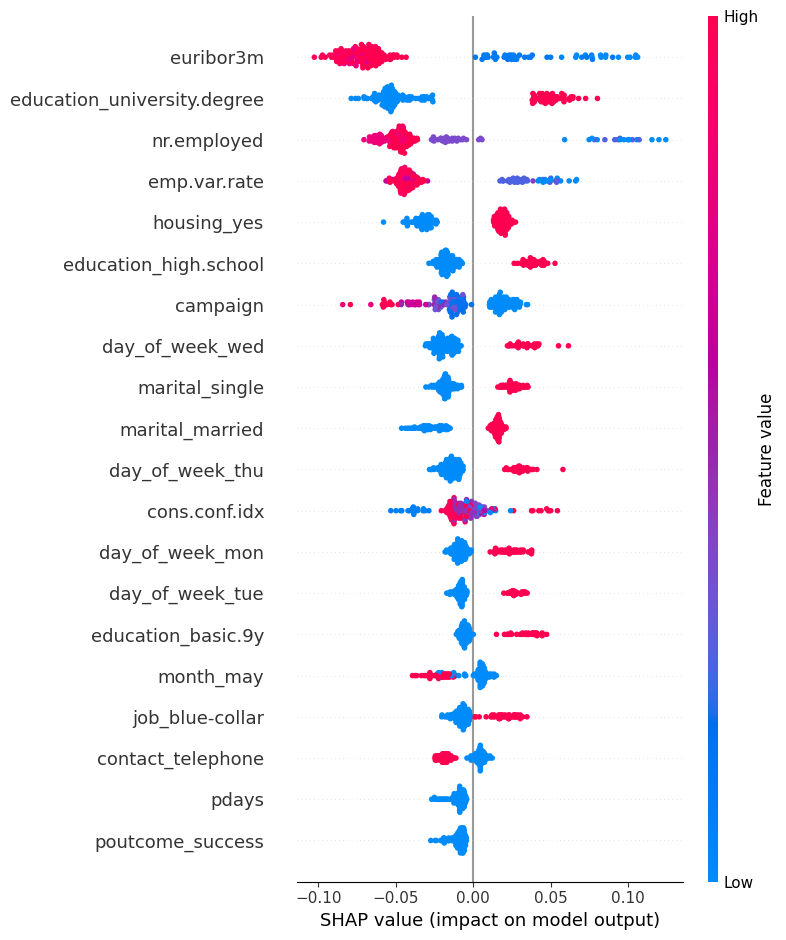

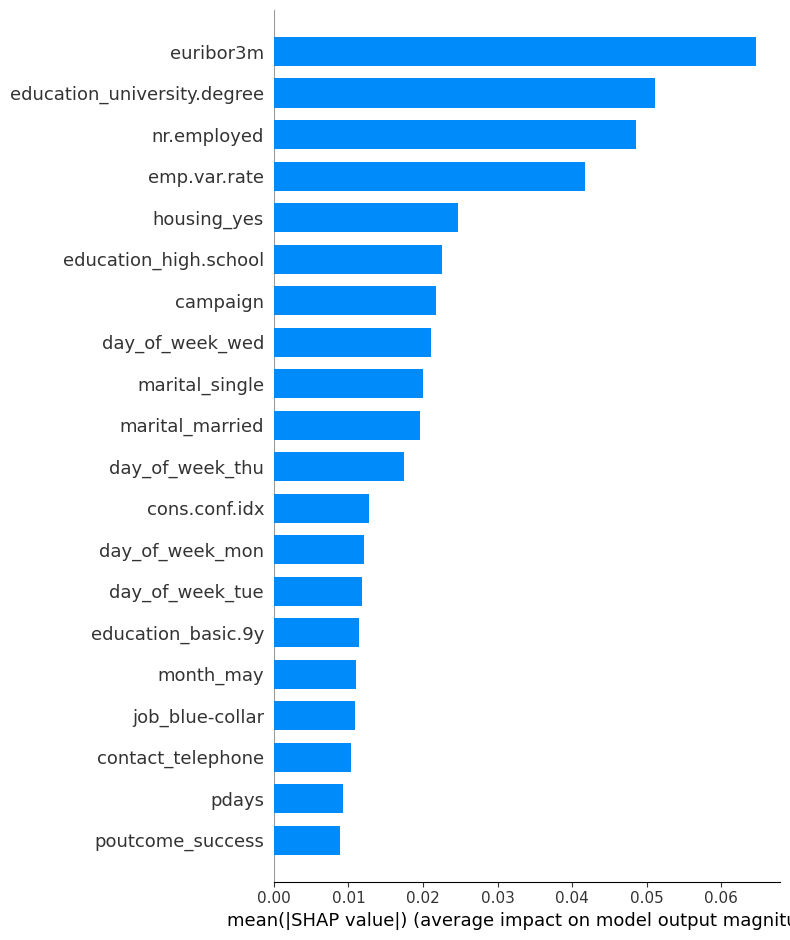

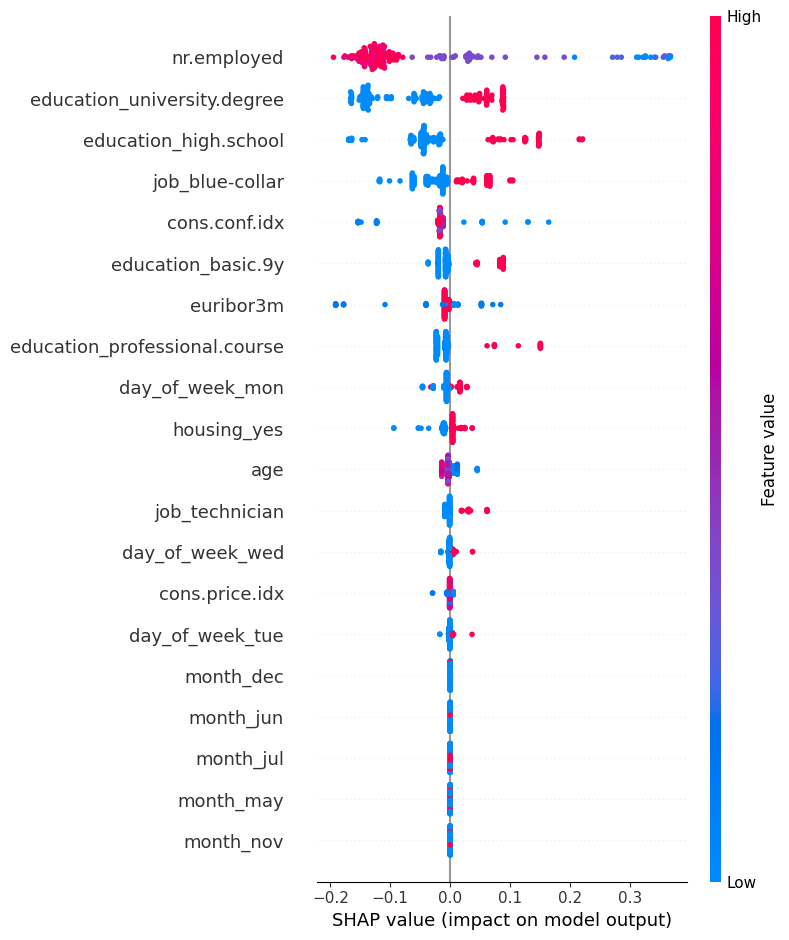

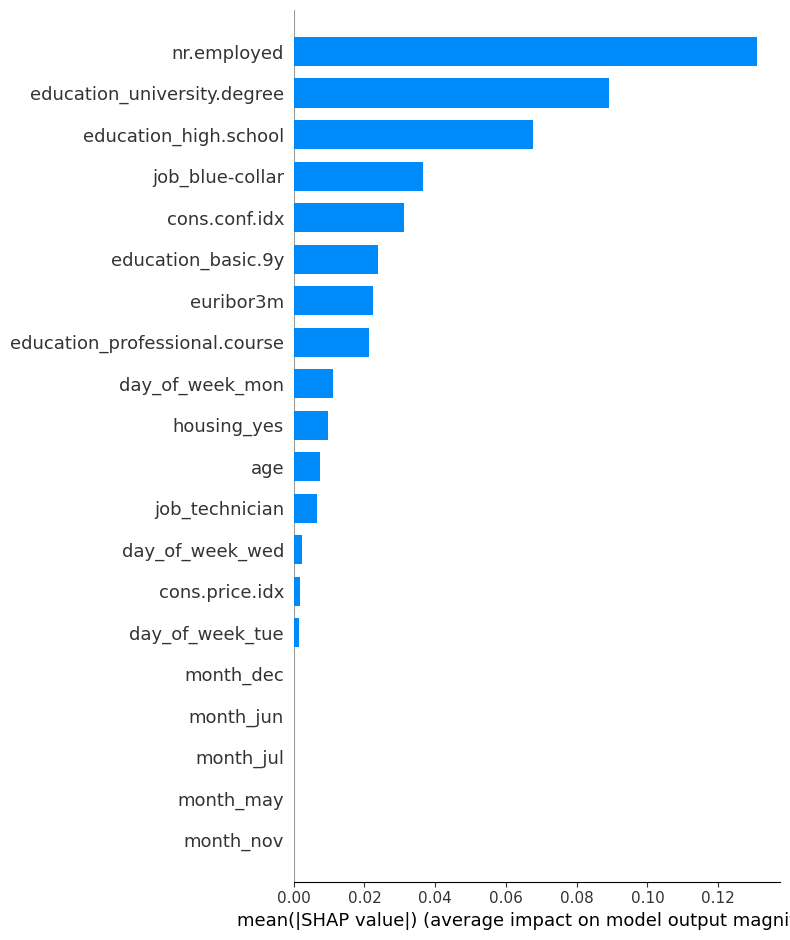

In [22]:
#SHAP for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_sample)
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_sample,
)
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_sample,
    plot_type="bar"
)
#SHAP for Decision tree
explainer_dt = shap.TreeExplainer(dt_model)
shap_values_dt = explainer_dt.shap_values(X_sample)

shap.summary_plot(
    shap_values_dt[:, :, 1],
    X_sample
)
shap.summary_plot(
    shap_values_dt[:, :, 1],
    X_sample,
    plot_type="bar"
)

In [23]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=np.array(X_train),

    feature_names=X_train.columns,

    class_names=['0', '1'],

    mode='classification'
)
instance = X_test.iloc[0]

#LIME For Random Forest
lime_exp_rf = lime_explainer.explain_instance(

    data_row=instance,

    predict_fn=rf_pipeline.predict_proba
)
lime_exp_rf.show_in_notebook(show_table=True)

#LIME for Decision Tree
lime_exp_dt = lime_explainer.explain_instance(

    data_row=instance,

    predict_fn=dt_pipeline.predict_proba
)

lime_exp_dt.show_in_notebook(show_table=True)

Output hidden; open in https://colab.research.google.com to view.